In [13]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
from iminuit import Minuit
from iminuit.cost import LeastSquares

In [14]:
def plot_fit (x_coord, y_coord, y_sigma, fit_function, minuit_object, title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 0.0, yerr = y_sigma, linestyle = 'None', marker = 'o')

    x_fit = np.linspace (x_coord[0], x_coord[-1], 1000)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="red", linewidth=2)
    ax.set_xlabel ("t (s)")
    ax.set_ylabel ("V (ohm)")
    ax.set_title (title)

    #plt.savefig("R=5k_cb_C1.png")
    plt.show()
    #plt.close(fig)

In [15]:
C =1.04e-7 #F
C_fit = 1.0308338202525391e-07
erroreC_fit = 6.292667376458447e-10
L_fit = 0.01786042544114515 #H
erroreL_fit = 0.0008195801544976015 #H
Rcriticausata = 500
Rsottosmorzato = 30
Rsovrasmorzato = 2000

In [16]:
#stima di Rcirucito critico
Rcritica= 2*np.sqrt(L_fit/C)
print('resistenza interna circuito RLC critico: ', Rcritica, 'ohm')

resistenza interna circuito RLC critico:  828.8180982845658 ohm


In [17]:
#RLC_critico
def critRLC(t, K, alpha):
    return K * t * np.exp(-alpha * t)

In [18]:
with open('C2RLCcriticocopia.txt') as input_file:
    TLClist = []
    TLCerrlist = []
    VLClist = []
    VLCerrlist = []
    for riga in input_file:
        valoriLC = riga.split()
        TLClist.append(float(valoriLC[0]))
        TLCerrlist.append(float(valoriLC[1]))
        VLClist.append(float(valoriLC[2]))
        VLCerrlist.append(float(valoriLC[3]))

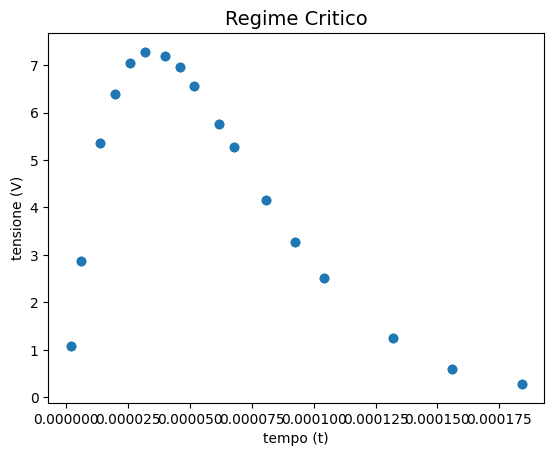

In [19]:
VLC = VLClist
TLC = TLClist

TLC = np.array(TLClist)
VLC = np.array(VLClist)

TLC_err = np.array(TLCerrlist)
VLC_err = np.array(VLCerrlist)


fig, ax = plt.subplots () 
ax.set_title ('Regime Critico', size=14)
ax.set_ylabel ('tensione (V)')
ax.set_xlabel ('tempo (t)')
ax.scatter(TLC, VLC)
ax.errorbar (TLC, VLC, xerr = TLC_err, yerr = VLC_err, linestyle = 'None',marker = 'o')
#plt.savefig("aaa.png")
plt.show()
#plt.close(fig)

In [20]:
least_squares = LeastSquares (TLC, VLC, VLC_err, critRLC)
my_minuit = Minuit (least_squares, K=1., alpha =1.)
#my_minuit.limits["tau"] = (1e-6, None)
my_minuit.migrad ()  
my_minuit.hesse () 


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
alpha_fit = my_minuit.values[1]
errK = my_minuit.errors[0]
erralpha = my_minuit.errors[1]

print (my_minuit.covariance)


display (my_minuit)

success of the fit:  True
value of the fit Q-squared 130.6031585466152
value of the number of degrees of freedom 15.0
associated p-value:  0.0
K = 605687.083 +/- 2282.452
alpha = 30542.845 +/- 79.346
┌───────┬───────────────────┐
│       │        K    alpha │
├───────┼───────────────────┤
│     K │ 5.21e+06    156e3 │
│ alpha │    156e3  6.3e+03 │
└───────┴───────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 130.6 (χ²/ndof = 8.7)      │              Nfcn = 123              │
│ EDM = 4.11e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │  605.7e3  │   2.3e3   │            │            │         │         │       │
│ 1 │ alpha │  30.54e3  │  0.08e3   │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────┐
│       │        K    alpha │
├───────┼───────────────────┤
│     K │ 5.21e+06    156e3 │
│ alpha │    156e3  6.3e+03 │
└───────┴───────────────────┘

In [21]:
def dV_dt (t):
    return K_fit * np.exp(-alpha_fit * t) * (1-(alpha_fit*t))
err_crit_RLC = np.sqrt((VLC_err**2) + ((dV_dt(TLC) * TLC_err)**2))

least_squares = LeastSquares (TLC, VLC, err_crit_RLC, critRLC) #!! da corregere l'errore propagato
my_minuit = Minuit (least_squares, K=K_fit, alpha =alpha_fit)
#my_minuit.limits["tau"] = (1e-6, None)
my_minuit.migrad ()  
my_minuit.hesse () 


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
alpha_fit = my_minuit.values[1]
errK = my_minuit.errors[0]
erralpha = my_minuit.errors[1]

print (my_minuit.covariance)


display (my_minuit)

success of the fit:  True
value of the fit Q-squared 128.86834456622998
value of the number of degrees of freedom 15.0
associated p-value:  0.0
K = 605155.599 +/- 2321.010
alpha = 30527.117 +/- 80.331
┌───────┬───────────────────┐
│       │        K    alpha │
├───────┼───────────────────┤
│     K │ 5.39e+06    161e3 │
│ alpha │    161e3 6.45e+03 │
└───────┴───────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 128.9 (χ²/ndof = 8.6)      │              Nfcn = 42               │
│ EDM = 9.87e-09 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │  605.2e3  │   2.3e3   │            │            │         │         │       │
│ 1 │ alpha │  30.53e3  │  0.08e3   │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────┐
│       │        K    alpha │
├───────┼───────────────────┤
│     K │ 5.39e+06    161e3 │
│ alpha │    161e3 6.45e+03 │
└───────┴───────────────────┘

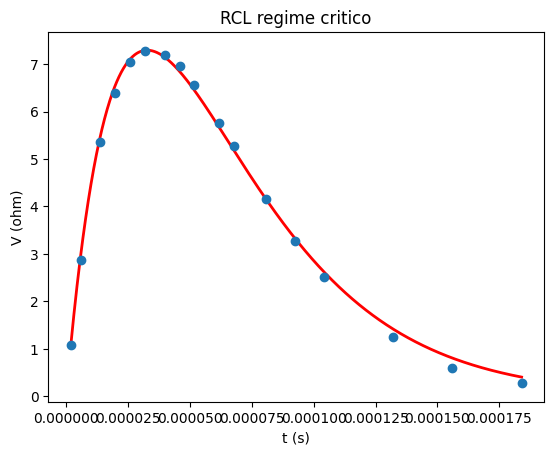

In [22]:
plot_fit(TLC , VLC, err_crit_RLC ,critRLC , my_minuit, "RCL regime critico")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [23]:
#t student
alpha_a = 1/np.sqrt(L_fit*C_fit)
sigma_alpha_a = alpha_a * 0.5 * np.sqrt((erroreL_fit / L_fit)**2 + (erroreC_fit / C_fit)**2)
t_student_alpha_a = (alpha_fit - alpha_a)/(np.sqrt(erralpha**2+sigma_alpha_a**2))
print(sigma_alpha_a)
print('alpha_fit: ', alpha_fit ,'alpha atteso:' , alpha_a, 't student alpha =' , t_student_alpha_a)

#essendo la resistenza sflasata di circa 300 ohm provo a fare questi calcoli
alpha_b= Rcritica/(2*L_fit)
t_student_alpha_b = (alpha_fit - alpha_b)/(np.sqrt(erralpha**2+sigma_alpha_a**2))
print('alpha_fit: ', alpha_fit ,'alpha atteso:' , alpha_b, 't student alpha =' , t_student_alpha_b)
#se sostituisco Rcritica con 500 sperimentale esce anche peggio

539.4343503293416
alpha_fit:  30527.1166924803 alpha atteso: 23305.572229816655 t student alpha = 13.241237646552378
alpha_fit:  30527.1166924803 alpha atteso: 23202.641533252994 t student alpha = 13.429968716667798


In [24]:
# REGIME SOTTOSMORZATO
def undrRLC(t, K, alpha, omega):
    return K * np.exp(-alpha * t) * np.sin(omega * t)

In [25]:
with open('C2RLCsottocopia.txt') as input_file:
    TLClist1 = []
    TLCerrlist1 = []
    VLClist1 = []
    VLCerrlist1 = []
    for riga in input_file:
        valoriLC = riga.split()
        TLClist1.append(float(valoriLC[0]))
        TLCerrlist1.append(float(valoriLC[1]))
        VLClist1.append(float(valoriLC[2]))
        VLCerrlist1.append(float(valoriLC[3]))

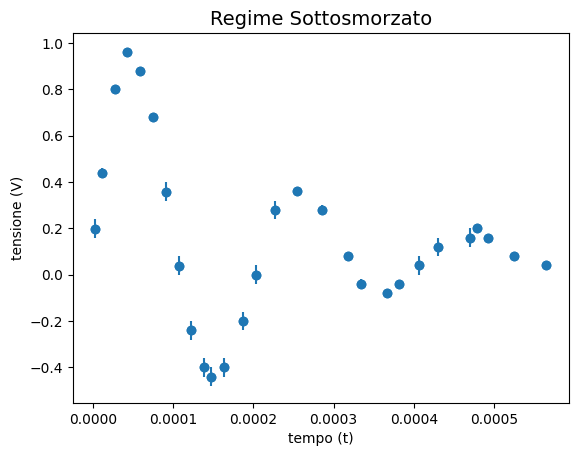

In [26]:
TLC = np.array(TLClist1)
VLC = np.array(VLClist1)
VLC_err = np.array(VLCerrlist1)
TLC_err = np.array(TLClist1)


fig, ax = plt.subplots () 
ax.set_title ('Regime Sottosmorzato', size=14)
ax.set_ylabel ('tensione (V)')
ax.set_xlabel ('tempo (t)')
ax.scatter(TLC, VLC)
ax.errorbar (TLC, VLC, yerr = VLC_err, linestyle = 'None',marker = 'o')
#plt.savefig("aaa.png")
plt.show()
#plt.close(fig)

In [27]:
least_squares = LeastSquares (TLC, VLC, VLC_err, undrRLC)
my_minuit = Minuit (least_squares, K=0.4, alpha =1.2e4, omega = 5.4e4)
#my_minuit.limits["tau"] = (1e-6, None)
my_minuit.migrad ()  
my_minuit.hesse () 


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
alpha_fit = my_minuit.values[1]
omega_fit = my_minuit.values[2]
errK = my_minuit.errors[0]
erralpha = my_minuit.errors[1]
erromega = my_minuit.errors[2]

print (my_minuit.covariance)


display (my_minuit)

success of the fit:  True
value of the fit Q-squared 579.7630491027601
value of the number of degrees of freedom 25.0
associated p-value:  0.0
K = 1.294 +/- 0.011
alpha = 5902.577 +/- 111.662
omega = 28989.917 +/- 105.268
┌───────┬───────────────────────────────┐
│       │         K     alpha     omega │
├───────┼───────────────────────────────┤
│     K │   0.00013 956.35e-3  53.09e-3 │
│ alpha │ 956.35e-3  1.25e+04   0.001e6 │
│ omega │  53.09e-3   0.001e6  1.11e+04 │
└───────┴───────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 579.8 (χ²/ndof = 23.2)     │              Nfcn = 163              │
│ EDM = 1.47e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │   1.294   │   0.011   │            │            │         │         │       │
│ 1 │ alpha │  5.90e3   │  0.11e3   │            │            │         │         │       │
│ 2 │ omega │  28.99e3  │  0.10e3   │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────────────────┐
│       │         K     alpha     omega │
├───────┼───────────────────────────────┤
│     K │   0.00013 956.35e-3  53.09e-3 │
│ alpha │ 956.35e-3  1.25e+04   0.001e6 │
│ omega │  53.09e-3   0.001e6  1.11e+04 │
└───────┴───────────────────────────────┘

In [28]:
def dV_dt (t):
    return K_fit * np.exp(-alpha_fit * t) * (np.cos(omega_fit*t)-(alpha_fit*t*np.sin(omega_fit*t)))
err_undr_RLC = np.sqrt((VLC_err**2) + ((dV_dt(TLC) * TLC_err)**2))

least_squares = LeastSquares (TLC, VLC, err_undr_RLC, undrRLC) #!! da corregere l'errore propagato
my_minuit = Minuit (least_squares, K=K_fit, alpha =alpha_fit, omega = omega_fit)
my_minuit.migrad ()  
my_minuit.hesse () 


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
alpha_fit = my_minuit.values[1]
omega_fit = my_minuit.values[2]
errK = my_minuit.errors[0]
erralpha = my_minuit.errors[1]
erromega = my_minuit.errors[2]

print (my_minuit.covariance)


display (my_minuit)

#da capire perchè non cambia chi quad dopo secondo fit

success of the fit:  True
value of the fit Q-squared 579.7217153793193
value of the number of degrees of freedom 25.0
associated p-value:  0.0
K = 1.294 +/- 0.011
alpha = 5902.623 +/- 111.669
omega = 28989.914 +/- 105.269
┌───────┬───────────────────────────────┐
│       │         K     alpha     omega │
├───────┼───────────────────────────────┤
│     K │   0.00013 956.44e-3  53.08e-3 │
│ alpha │ 956.44e-3  1.25e+04   0.001e6 │
│ omega │  53.08e-3   0.001e6  1.11e+04 │
└───────┴───────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 579.7 (χ²/ndof = 23.2)     │              Nfcn = 51               │
│ EDM = 4.78e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │   1.294   │   0.011   │            │            │         │         │       │
│ 1 │ alpha │  5.90e3   │  0.11e3   │            │            │         │         │       │
│ 2 │ omega │  28.99e3  │  0.10e3   │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────────────────┐
│       │         K     alpha     omega │
├───────┼───────────────────────────────┤
│     K │   0.00013 956.44e-3  53.08e-3 │
│ alpha │ 956.44e-3  1.25e+04   0.001e6 │
│ omega │  53.08e-3   0.001e6  1.11e+04 │
└───────┴───────────────────────────────┘

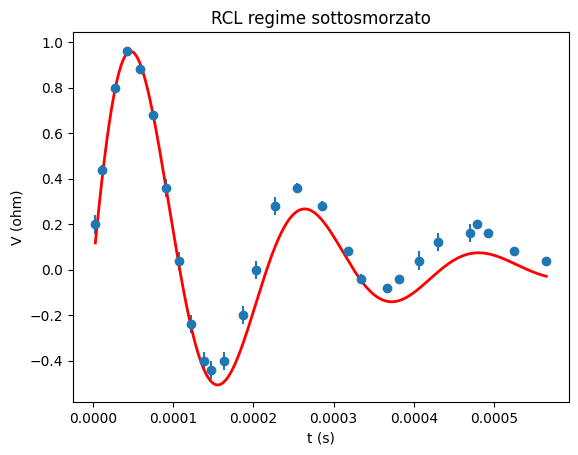

In [29]:
plot_fit(TLC , VLC, err_undr_RLC ,undrRLC , my_minuit, "RCL regime sottosmorzato")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [30]:
L_fitsotto = Rsottosmorzato / (2*alpha_fit)
C_sotto = 1/(L_fitsotto * (omega_fit**2 + alpha_fit**2))
# Formule per la propagazione degli errori - circuito RLC sottosmorzato

# Errore su L
sigma_L = L_fit * (erralpha/ alpha_fit)

# Errore su C (forma compatta)
sigma_C = C_fit * np.sqrt((erralpha / alpha_fit)**2 + 4 * (omega_fit**2 * erromega**2 + alpha_fit**2 * erralpha**2) / (omega_fit**2 + alpha_fit**2)**2)
print (L_fitsotto, '+/-', sigma_L, C_sotto,'+/-', sigma_C )

0.002541243277121018 +/- 0.00033789241006505825 4.4959204854010665e-07 +/- 2.08423866758802e-09


In [31]:
#t student
t_student_L_sotto = (-L_fitsotto+L_fit)/np.sqrt(sigma_L**2 + erroreL_fit**2)
t_student_C_sotto = (C_sotto-C_fit)/np.sqrt(sigma_C**2 + erroreC_fit**2)
print (t_student_L_sotto, t_student_C_sotto)


17.280514074671093 159.1562408236284


In [32]:
# REGIME SOVRASMORZATO
def ovrRLC(t, K, lamb1, lamb2, t0):
    return K * (np.exp(lamb1 * (t - t0)) - np.exp(lamb2 * (t - t0)))

In [33]:
#RLC_sovra
with open('C2RLCsovracopia.txt') as input_file:
    TLClist2 = []
    TLCerrlist2 = []
    VLClist2 = []
    VLCerrlist2 = []
    for riga in input_file:
        valoriLC = riga.split()
        TLClist2.append(float(valoriLC[0]))
        TLCerrlist2.append(float(valoriLC[1]))
        VLClist2.append(float(valoriLC[2]))
        VLCerrlist2.append(float(valoriLC[3]))

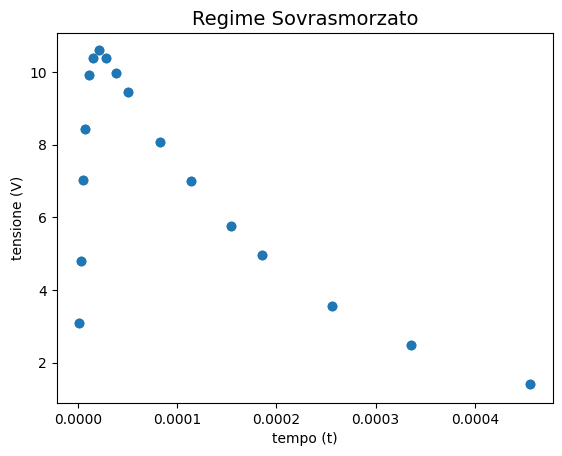

In [34]:
VLC = np.array(VLClist2)
TLC = np.array(TLClist2)
TLC_err = np.array(TLCerrlist2)
VLC_err = np.array(VLCerrlist2)

fig, ax = plt.subplots () 
ax.set_title ('Regime Sovrasmorzato', size=14)
ax.set_ylabel ('tensione (V)')
ax.set_xlabel ('tempo (t)')
ax.scatter(TLC, VLC)
ax.errorbar (TLC, VLC, yerr = VLC_err, linestyle = 'None',marker = 'o')
#plt.savefig("aaa.png")
plt.show()
#plt.close(fig)

In [35]:
least_squares = LeastSquares (TLC, VLC, VLC_err, ovrRLC)
my_minuit = Minuit(least_squares, K=15.0, lamb1=-20000.0, lamb2=-100000.0, t0=-1e-5)
#my_minuit.limits["tau"] = (1e-6, None)
my_minuit.limits["lamb1"] = (None, 0.0)
my_minuit.limits["lamb2"] = (None, 0.0)
my_minuit.limits["t0"] = (None, TLC[0])
my_minuit.migrad ()  
my_minuit.hesse () 


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
lamb1_fit = my_minuit.values[1]
lamb2_fit = my_minuit.values[2]
t0_fit = my_minuit.values[3]
errK = my_minuit.errors[0]
errlamb1 = my_minuit.errors[1]
errlamb2 = my_minuit.errors[2]
errt0 = my_minuit.errors[3]

print (my_minuit.covariance)


display (my_minuit)

success of the fit:  True
value of the fit Q-squared 57.93256444421857
value of the number of degrees of freedom 13.0
associated p-value:  1.226912494933785e-07
K = 11.938 +/- 0.015
lamb1 = -4690.397 +/- 22.509
lamb2 = -191616.177 +/- 1564.509
t0 = -0.000 +/- 0.000
┌───────┬─────────────────────────────────────────────────────────────────────────┐
│       │                 K             lamb1             lamb2                t0 │
├───────┼─────────────────────────────────────────────────────────────────────────┤
│     K │          0.000224        -243.93e-3          18.54462     -331.9458e-12 │
│ lamb1 │        -243.93e-3               507           -13.6e3    194.2050986e-9 │
│ lamb2 │          18.54462           -13.6e3          2.45e+06 -51.1393232141e-6 │
│    t0 │     -331.9458e-12    194.2050986e-9 -51.1393232141e-6          1.47e-15 │
└───────┴─────────────────────────────────────────────────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 57.93 (χ²/ndof = 4.5)      │              Nfcn = 242              │
│ EDM = 1.57e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │  11.938   │   0.015   │            │            │         │         │       │
│ 1 │ lamb1 │ -4.690e3  │  0.023e3  │            │            │         │    0    │       │
│ 2 │ lamb2 │ -191.6e3  │   1.6e3   │            │            │         │    0    │       │
│ 3 │ t0    │ -0.08e-6  │  0.04e-6  │            │            │         │ 1.6e-06 │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────────────────────────────────────────┐
│       │                 K             lamb1             lamb2                t0 │
├───────┼─────────────────────────────────────────────────────────────────────────┤
│     K │          0.000224        -243.93e-3          18.54462     -331.9458e-12 │
│ lamb1 │        -243.93e-3               507           -13.6e3    194.2050986e-9 │
│ lamb2 │          18.54462           -13.6e3          2.45e+06 -51.1393232141e-6 │
│    t0 │     -331.9458e-12    194.2050986e-9 -51.1393232141e-6          1.47e-15 │
└───────┴─────────────────────────────────────────────────────────────────────────┘

In [36]:
def dV_dt(t):
    return K_fit * (lamb1_fit * np.exp(lamb1_fit * (t - t0_fit)) - lamb2_fit * np.exp(lamb2_fit * (t - t0_fit)))

err_ovr_RLC = np.sqrt((VLC_err**2) + ((dV_dt(TLC) * TLC_err)**2))

least_squares = LeastSquares(TLC, VLC, err_ovr_RLC, ovrRLC)
my_minuit = Minuit(least_squares, K=K_fit, lamb1=lamb1_fit, lamb2=lamb2_fit, t0=t0_fit)

my_minuit.migrad()
my_minuit.hesse()


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
alpha_fit = my_minuit.values[1]
omega_fit = my_minuit.values[2]
errK = my_minuit.errors[0]
erralpha = my_minuit.errors[1]
erromega = my_minuit.errors[2]

print (my_minuit.covariance)


display (my_minuit)

#da capire perchè non cambia chi quad dopo secondo fit

success of the fit:  True
value of the fit Q-squared 55.9382148836568
value of the number of degrees of freedom 13.0
associated p-value:  2.763833433228058e-07
K = 11.940 +/- 0.015
lamb1 = -4691.767 +/- 22.544
lamb2 = -191271.761 +/- 1588.088
t0 = -0.000 +/- 0.000
┌───────┬─────────────────────────────────────────────────────────────────────────┐
│       │                 K             lamb1             lamb2                t0 │
├───────┼─────────────────────────────────────────────────────────────────────────┤
│     K │          0.000228        -246.27e-3          19.05398     -345.8779e-12 │
│ lamb1 │        -246.27e-3               508           -13.9e3    200.5707066e-9 │
│ lamb2 │          19.05398           -13.9e3          2.52e+06 -53.2871025334e-6 │
│    t0 │     -345.8779e-12    200.5707066e-9 -53.2871025334e-6          1.56e-15 │
└───────┴─────────────────────────────────────────────────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 55.94 (χ²/ndof = 4.3)      │              Nfcn = 104              │
│ EDM = 1.01e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │  11.940   │   0.015   │            │            │         │         │       │
│ 1 │ lamb1 │ -4.692e3  │  0.023e3  │            │            │         │         │       │
│ 2 │ lamb2 │ -191.3e3  │   1.6e3   │            │            │         │         │       │
│ 3 │ t0    │ -0.08e-6  │  0.04e-6  │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────────────────────────────────────────┐
│       │                 K             lamb1             lamb2                t0 │
├───────┼─────────────────────────────────────────────────────────────────────────┤
│     K │          0.000228        -246.27e-3          19.05398     -345.8779e-12 │
│ lamb1 │        -246.27e-3               508           -13.9e3    200.5707066e-9 │
│ lamb2 │          19.05398           -13.9e3          2.52e+06 -53.2871025334e-6 │
│    t0 │     -345.8779e-12    200.5707066e-9 -53.2871025334e-6          1.56e-15 │
└───────┴─────────────────────────────────────────────────────────────────────────┘

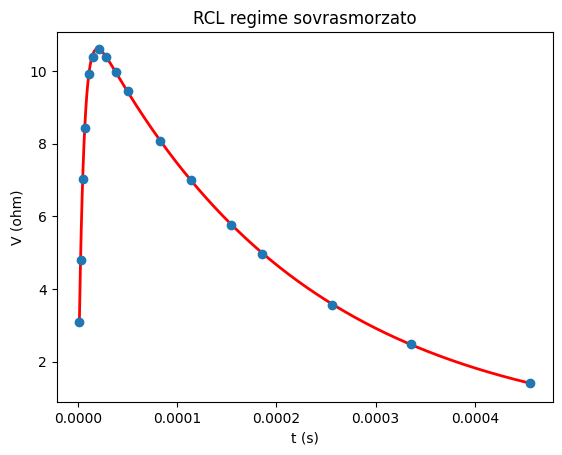

In [37]:
plot_fit(TLC , VLC, err_ovr_RLC ,ovrRLC , my_minuit, "RCL regime sovrasmorzato")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [39]:
L_fitsovra= (-Rsovrasmorzato)/(lamb1_fit+lamb2_fit)
C_fitsovra= -(lamb1_fit+lamb2_fit)/(lamb1_fit*lamb2_fit*Rsovrasmorzato)
# Formule per la propagazione degli errori - circuito RLC sovrasmorzato

# Errore su L
sigma_L = L_fit * np.sqrt(errlamb1**2 + errlamb2**2) / abs(lamb1_fit + lamb2_fit)

# Errore su C
sigma_C = C * np.sqrt((errlamb1**2 + errlamb2**2) / (lamb1_fit + lamb2_fit)**2 + (lamb2_fit**2 * errlamb1**2 + lamb1_fit**2 * errlamb2**2) / (lamb1_fit * lamb2_fit)**2)

print (L_fitsovra, '+/-', sigma_L, C_fitsovra, '+/-', sigma_C)

0.010188145817146574 +/- 0.00014235740904807313 1.0921016430745932e-07 +/- 1.2873475503570992e-09


In [40]:
#t student
t_student_L_sovra = (-L_fitsovra+L_fit)/np.sqrt(sigma_L**2 + erroreL_fit**2)
t_student_C_sovra = (C_fitsovra-C_fit)/np.sqrt(sigma_C**2 + erroreC_fit**2)
print (t_student_L_sovra, t_student_C_sovra)


9.223133840231517 4.275752451273695
